# CBE 60547 - Computational Chemistry Laboratory 4

## 1. Bulk Systems
### 1.1 Creating a bulk system

In [1]:
from ase.build import bulk
from ase.visualize import view
import matplotlib.pyplot as plt
import os
from ase.build.surface import add_adsorbate
from ase.build import molecule
from ase.build.surface import fcc111
from ase.io import write

In [2]:
import re
def OUTPUT(name):
    file_path = f"/Users/henry/Desktop/training_results/{name}"  # Update this to your actual file path
    
    with open(file_path, "r") as file:
        content = file.read()
    
    # Check convergence condition
    if 'reached required accuracy' in content:
        with open(file_path, "r") as file:  # Reopen the file or reset cursor
            extract = False
            final_toten_value = None  # Store the latest found value
            
            for line in file:
                if "FREE ENERGIE OF THE ION-ELECTRON SYSTEM" in line:
                    extract = True  
                elif extract and "energy(sigma->0) =" in line:
                    match = re.search(r"energy\(sigma->0\)\s*=\s*(-?\d+\.\d+)", line)
                    if match:
                        final_toten_value = float(match.group(1))  # Store the latest match (keep updating)
    
        if final_toten_value is not None:
            return final_toten_value
        else:
            return None
    
    else:
        print("Calculation is not converged")
        return None

In [ ]:
import numpy as np
A = np.linspace(3.7,4.1,9)
print(A)

In [ ]:
i = 3
print(A[i])
Pd_cubic = bulk('Pd','fcc',a=3.955,cubic=True)
view(Pd_cubic)

In [ ]:
volumes = []
for i in range(len(A)):
    Pd_cubic = bulk('Pd','fcc',a=A[i],cubic=True)
    volumes.append(Pd_cubic.get_volume())
print(volumes)

## 1.3 Optimizing lattice constatns - Equations of State
### 1.3.1 Energies vs. Lattice Constants

In [3]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/lattice_const") if f.startswith("OUTCAR")]
print(files)

['OUTCAR_4.05', 'OUTCAR_4.0', 'OUTCAR_4.1', 'OUTCAR_3.85', 'OUTCAR_3.8', 'OUTCAR_3.9', 'OUTCAR_3.7', 'OUTCAR_3.75', 'OUTCAR_3.95']


In [4]:
def lattice(name):
    file_path = f"/Users/henry/Desktop/training_results/{name}"
    with open(file_path, "r") as file:  # Reopen the file or reset cursor
        extract = False
        final_toten_value = None  # Store the latest found value
        
        for line in file:
            if "FREE ENERGIE OF THE ION-ELECTRON SYSTEM" in line:
                extract = True  
            elif extract and "energy(sigma->0) =" in line:
                match = re.search(r"energy\(sigma->0\)\s*=\s*(-?\d+\.\d+)", line)
                if match:
                    final_toten_value = float(match.group(1))  # Store the latest match (keep updating)

    if final_toten_value is not None:
        return final_toten_value
    else:
        return None

In [5]:
tot_en = {}
for a in files:
    energy = lattice(a)
    toten_value = energy
    tot_en[float(a[7:])] = toten_value
print(tot_en)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/henry/Desktop/training_results/OUTCAR_4.05'

In [ ]:
x = sorted([float(k) for k in tot_en.keys()])  # Sorted x values
y = [tot_en[k] for k in x]  # Get y values corresponding to sorted x
plt.plot(x, y, marker='o', linestyle='-', color='b', label="Energy values")
plt.xlabel("Lattice constant, a (Å)")
plt.ylabel("Total energy (eV)")
plt.title("Palladium, Pd")
plt.show()

### 1.3.2 Fitting to an Equation of State

In [ ]:
tot_en = dict(sorted(tot_en.items()))
print(tot_en)
print(volumes)

In [ ]:
from ase.eos import EquationOfState
eos = EquationOfState(volumes, [i for i in tot_en.values()], eos = 'birchmurnaghan')
v0 , e0, b = eos.fit()
a0 = v0 ** (1/3)

In [ ]:
print(f'minimum e = {e0:.3f}')
print(f'opt V = {v0:.3f}')
print(f'opt a = {a0:.3f}')

In [ ]:
eos.plot(filename='Pd-EOS.png',show=True)

### 1.3.3. Effects of KPOINTS

In [6]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/lattice_kpoints") if f.startswith("OUTCAR")]
print(files)

['OUTCAR_15', 'OUTCAR_30', 'OUTCAR_10', 'OUTCAR_20', 'OUTCAR_3', 'OUTCAR_5']


In [7]:
tot_en = {}
for a in files:
    energy = lattice(f'lattice_kpoints/{a}')
    toten_value = energy
    tot_en[float(a[7:])] = toten_value
print(tot_en)

{15.0: -20.720537, 30.0: -20.71980863, 10.0: -20.71021485, 20.0: -20.7198995, 3.0: -20.86686289, 5.0: -20.7464131}


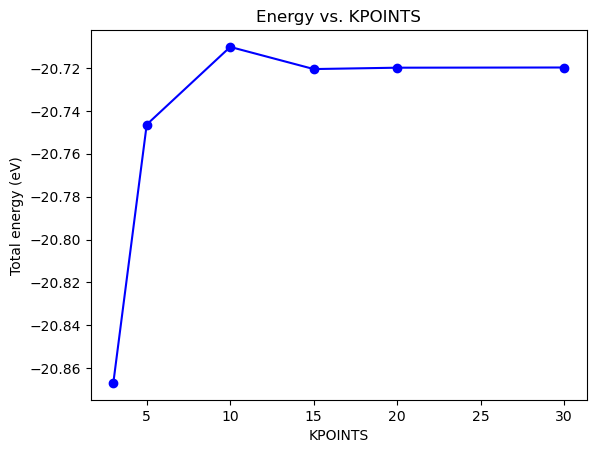

In [8]:
x = sorted([float(k) for k in tot_en.keys()])  # Sorted x values
y = [tot_en[k] for k in x]  # Get y values corresponding to sorted x
plt.plot(x, y, marker='o', linestyle='-', color='b', label="Energy values")
plt.xlabel("KPOINTS")
plt.ylabel("Total energy (eV)")
plt.title("Energy vs. KPOINTS")
plt.show()

### 1.3.3. Effects of KPOINTS (again with the size of (1,1,1))

In [9]:
tot_en = {}
tot_en[3] = -20.86766011
tot_en[6] = -20.74119614
tot_en[9] = -20.73519356
tot_en[12] = -20.72725702
tot_en[15] = -20.72044825

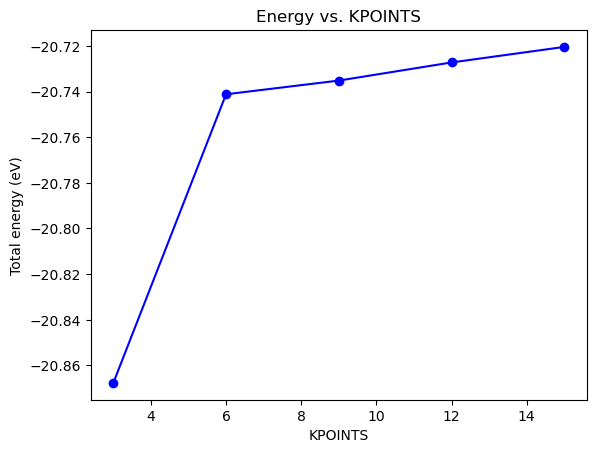

In [10]:
x = sorted([float(k) for k in tot_en.keys()])  # Sorted x values
y = [tot_en[k] for k in x]  # Get y values corresponding to sorted x
plt.plot(x, y, marker='o', linestyle='-', color='b', label="Energy values")
plt.xlabel("KPOINTS")
plt.ylabel("Total energy (eV)")
plt.title("Energy vs. KPOINTS")
plt.show()

## 2. Surfaces
### 2.1 Creating a surface

In [23]:
# create a surface with 3 unit cells in x and y
# 3 layers deep
a0 = 3.943
Pd_surface = fcc111('Pd',size=(3,3,5),vacuum=10.0,a=a0,orthogonal=False)
view(Pd_surface)

<Popen: returncode: None args: ['/opt/anaconda3/bin/python', '-m', 'ase', 'g...>

### 2.2. Surface calculations ***** I missed this step ******

In [44]:
OUTPUT("OUTCAR_surf")

-223.02421054

### 2.3. Adding an Adsorbate - O

In [ ]:
mole = molecule('O') 
Pd_surface = fcc111('Pd',size=(3,3,5),vacuum=10.0,a=a0,orthogonal=False)

# fcc and 111
pos=['fcc','hcp','ontop','bridge']

# hieght = van der Waals radii
add_adsorbate(Pd_surface, mole, height=1.2, position=pos[0])
view(Pd_surface)

In [ ]:
OUTPUT("OUTCAR_Pd_O")

In [ ]:
O2 = molecule("O2")

# Center the molecule in a larger vacuum box
O2.center(vacuum=10.0)
view(O2)

In [ ]:
OUTPUT("OUTCAR_O2")

In [ ]:
E_ads = E_Pd_O - E_surf - 0.5*E_O2
print(f'The adsorption energy of O on Pd surface: {E_ads:.3f}')

### 2.3. Adding an Adsorbate - N2 Parallel (90)

In [ ]:
mole = molecule('N2') 
mole.rotate(90,'y') # Parralel

Pd_surface = fcc111('Pd',size=(3,3,5),vacuum=10.0,a=a0,orthogonal=False)

# fcc and 111
pos=['fcc','hcp','ontop','bridge']

# hieght = van der Waals radii
add_adsorbate(Pd_surface, mole, height=2, position=pos[0])
view(Pd_surface)

In [67]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/N2-parallel/") if f.startswith("OUTCAR")]
print(files)

['OUTCAR_bridge', 'OUTCAR_hcp', 'OUTCAR_fcc', 'OUTCAR_top']


In [68]:
for name in files:
    print(name)
    e_val = OUTPUT(f'N2-parallel/{name}')
    if e_val != None:
        print(e_val)

OUTCAR_bridge
-239.75912987
OUTCAR_hcp
-239.90300523
OUTCAR_fcc
Calculation is not converged
OUTCAR_top
Calculation is not converged


### 2.3. Adding an Adsorbate - N2 Vertical (180)

In [ ]:
mole = molecule('N2') 
mole.rotate(180,'y') # Parralel

Pd_surface = fcc111('Pd',size=(3,3,5),vacuum=10.0,a=a0,orthogonal=False)

# fcc and 111
pos=['fcc','hcp','ontop','bridge']

# hieght = van der Waals radii
add_adsorbate(Pd_surface, mole, height=2, position=pos[0])
view(Pd_surface)

In [53]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/N2-vertical/") if f.startswith("OUTCAR")]
print(files)

['OUTCAR_bridge', 'OUTCAR_hcp', 'OUTCAR_fcc', 'OUTCAR_top']


In [55]:
for name in files:
    print(name)
    e_val = OUTPUT(f'N2-vertical/{name}')
    if e_val != None:
        print(e_val)

OUTCAR_bridge
Calculation is not converged
OUTCAR_hcp
-239.6202012
OUTCAR_fcc
-239.65446976
OUTCAR_top
-239.89815195


## 3. Convergence Test
### 3.1 Test with EDIFFG = -0.05,-0.03,-0.01, and KPOINTS = 5x5x1,4x4x1,3x3x1
### 3.1.1 3x3x1

In [62]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/convergence/") if f.startswith("OUTCAR_3")]
print(files)

['OUTCAR_3_0.03', 'OUTCAR_3_0.05']


In [63]:
for name in files:
    print(name)
    e_val = OUTPUT(f'convergence/{name}')
    if e_val != None:
        print(e_val)

OUTCAR_3_0.03
-239.75119138
OUTCAR_3_0.05
-239.74655169


### 3.1.2 4x4x1

In [56]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/convergence/") if f.startswith("OUTCAR_4")]
print(files)

['OUTCAR_4_0.01', 'OUTCAR_4_0.03', 'OUTCAR_4_0.05']


In [57]:
for name in files:
    print(name)
    e_val = OUTPUT(f'convergence/{name}')
    if e_val != None:
        print(e_val)

OUTCAR_4_0.01
Calculation is not converged
OUTCAR_4_0.03
-239.76370679
OUTCAR_4_0.05
-239.75912987


### 3.1.2 5x5x1

In [60]:
files = [f for f in os.listdir("/Users/henry/Desktop/training_results/convergence/") if f.startswith("OUTCAR_5")]
print(files)

['OUTCAR_5_0.05']


In [61]:
for name in files:
    print(name)
    e_val = OUTPUT(f'convergence/{name}')
    if e_val != None:
        print(e_val)

OUTCAR_5_0.05
-239.82306508
